In [1]:
import os
import numpy as np
import pandas as pd
from pyextremes import EVA

%matplotlib inline

In [2]:
infile = r'C:\Users\luxi\ClimateRisk\Data\Precipitation\GHCNd\NewZealand_metric.csv'
df = pd.read_csv(infile,usecols=['NAME','LATITUDE','LONGITUDE','ELEVATION','DATE','PRCP'],parse_dates=['DATE'])

In [3]:
stations = df[['NAME','LATITUDE','LONGITUDE','ELEVATION']]
stations = stations.drop_duplicates().reset_index(drop=True)

In [4]:
data = df[df.NAME == stations.loc[7,'NAME']].copy()
data = data[['DATE','PRCP']].dropna(subset='PRCP').set_index('DATE')
data = data.sort_index(ascending=True)
series = data.squeeze()

(<Figure size 768x480 with 1 Axes>,
 <AxesSubplot: xlabel='DATE', ylabel='PRCP'>)

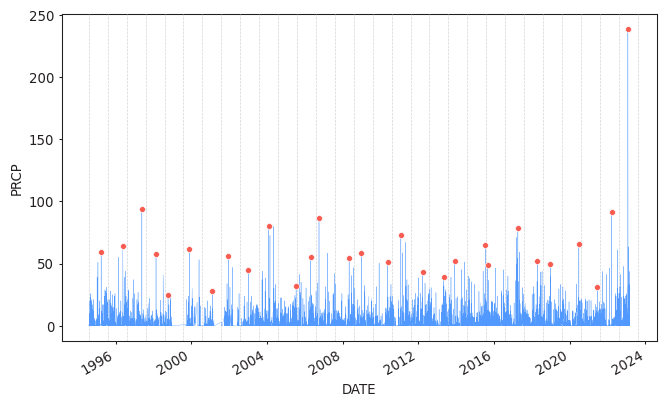

In [5]:
model = EVA(series)
model.get_extremes(method='BM',block_size="365.2425D")
model.plot_extremes()

In [ ]:
model.fit_model()
rps = [2,5,10,25,50,100,250,500,1000]
summary = model.get_summary(return_period=rps,alpha=0.95,n_samples=1000)
print(summary)
model.plot_diagnostic(alpha=0.95)